# GRF bi-material dataset — TPU × PLA

**Goal.** Build the first ML-ready dataset of random two-phase composites.

* **Microstructure** is a thresholded Gaussian Random Field (GRF).  Two knobs
  control the pattern:
    * `correlation_length` — feature size in pixels.
    * `volume_fraction` — fraction of the *soft* phase (A).
* **Phase A = TPU** (thermoplastic polyurethane): E ≈ 30 MPa, ν ≈ 0.48.
* **Phase B = PLA** (polylactic acid):           E ≈ 3500 MPa, ν ≈ 0.36.

~100× modulus contrast gives strong stress-concentration features that the
downstream video model needs to learn.

Units are MPa–mm–ms (density in Mg/mm³).  All solvers in this package use
the same system.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from fem_sim import (
    make_grf_bimat,
    make_cantilever_distributed,
    run_simulation,
    build_dataset,            # notebook-friendly wrapper for `fem-sim build-dataset`
    N_GEO_CHANNELS, CH_SOLID, CH_MATID, CH_E, CH_NU, CH_RHO,
    N_BC_CHANNELS,  CH_DISP_MASK, CH_FORCE_MASK, CH_DX, CH_DY, CH_FX, CH_FY,
)

plt.rcParams["figure.dpi"] = 100
OUT = Path("../outputs/notebook_grf_bimat")
OUT.mkdir(parents=True, exist_ok=True)


## 1. One sample — all five geometry channels

geometry shape: (5, 48, 96)
material IDs present: [1. 2.]


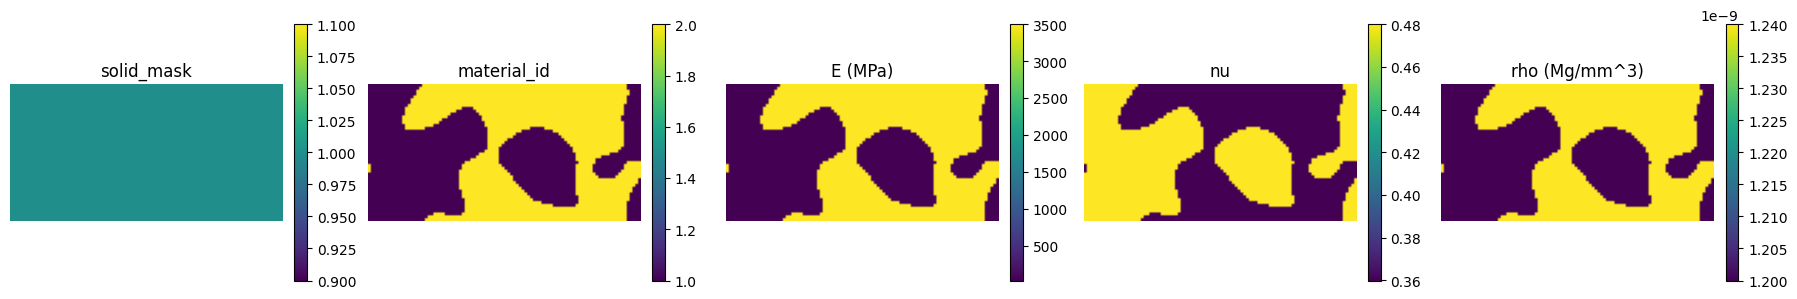

In [2]:
geo = make_grf_bimat(h=48, w=96, correlation_length=6.0, volume_fraction=0.5, seed=0)
print("geometry shape:", geo.shape)
print("material IDs present:", np.unique(geo[CH_MATID]))

titles = ["solid_mask", "material_id", "E (MPa)", "nu", "rho (Mg/mm^3)"]
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, ax in enumerate(axes):
    im = ax.imshow(geo[i], origin="lower", cmap="viridis")
    ax.set_title(titles[i])
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 2. The two knobs: correlation length × volume fraction

Rows vary `correlation_length` (smaller = finer speckle).
Columns vary `volume_fraction` (fraction of soft TPU).


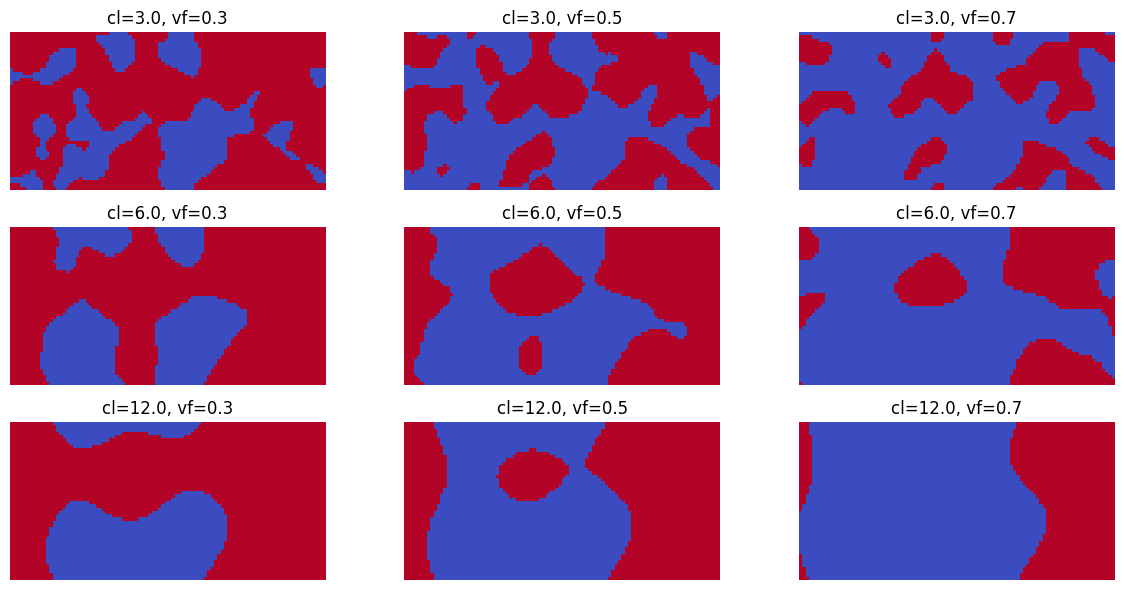

In [3]:
cls = [3.0, 6.0, 12.0]
vfs = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(len(cls), len(vfs), figsize=(12, 6))
for i, cl in enumerate(cls):
    for j, vf in enumerate(vfs):
        g = make_grf_bimat(h=48, w=96, correlation_length=cl, volume_fraction=vf, seed=42)
        axes[i, j].imshow(g[CH_MATID], origin="lower", cmap="coolwarm", vmin=1, vmax=2)
        axes[i, j].set_title(f"cl={cl}, vf={vf}")
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()


## 3. Attach a load case

Use a cantilever: left edge clamped, distributed downward load along the
right edge.  `make_cantilever_distributed` returns a `(6, H, W)` tensor
with disp/force masks and prescribed values per pixel.


bc shape: (6, 48, 96)


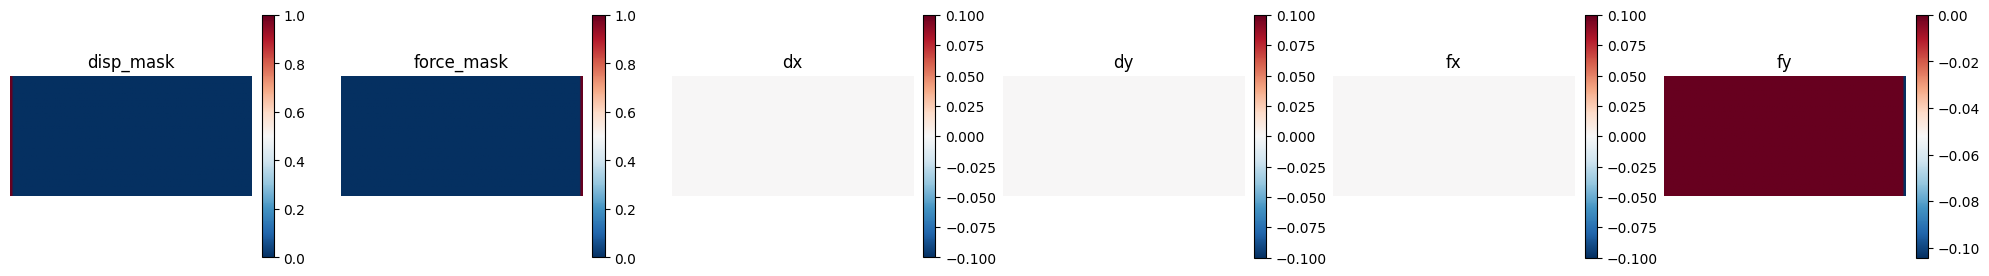

In [4]:
bc = make_cantilever_distributed(geo, load_mag=-5.0, direction="y")
print("bc shape:", bc.shape)

titles = ["disp_mask", "force_mask", "dx", "dy", "fx", "fy"]
fig, axes = plt.subplots(1, 6, figsize=(20, 3))
for i, ax in enumerate(axes):
    im = ax.imshow(bc[i], origin="lower", cmap="RdBu_r")
    ax.set_title(titles[i]); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 4. Solve with JAX-FEM

Quasi-static ramp in 5 steps.  Same pixel grid on output.


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



[04-24 15:37:49][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.
[04-24 15:37:49][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-24 15:37:49][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[04-24 15:37:49][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[04-24 15:37:49][DEBUG] jax_fem: Done pre-computations, took 0.011482954025268555 [s]
[04-24 15:37:49][INFO] jax_fem: Solving a problem with 4608 cells, 4753x2 = 9506 dofs.
[04-24 15:37:49][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[04-24 15:37:49][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-24 15:37:49][DEBUG] jax_fem: Start timing
[04-24 15:37:49][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-24 15:37:50][DEBUG] jax_fem: Function split_and_compute_cell took 0.2981 seconds
[04-24 15:37:50][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-24

fields shape: (5, 5, 48, 96)
metadata: {'nx': 96, 'ny': 48, 'steps': 5, 'run_dir': '/Users/jt35560/WorkSpace/fem-sim/outputs/notebook_grf_bimat/single_run', 'backend': 'jaxfem'}


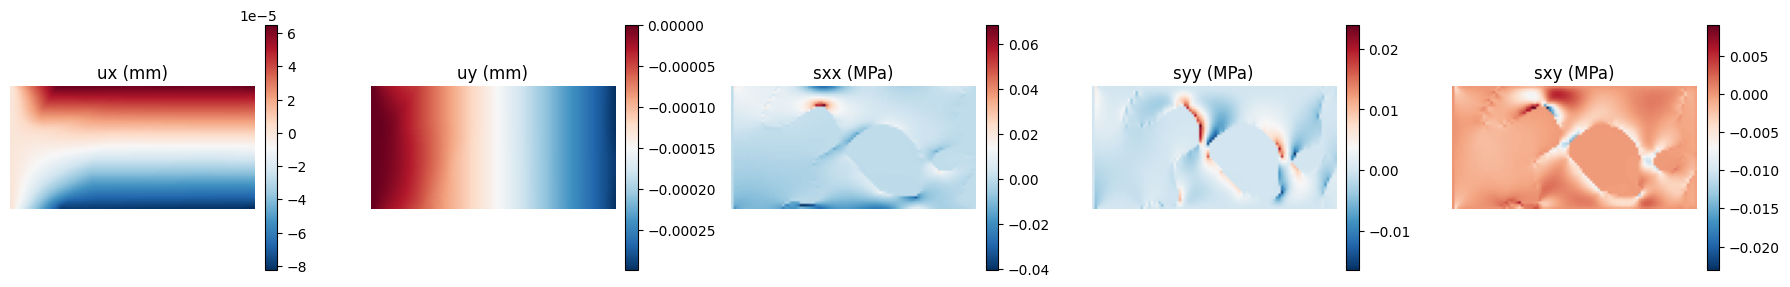

In [5]:
sample = run_simulation(geo, bc, steps=5, run_dir=OUT / "single_run", backend="jaxfem")
print("fields shape:", sample.fields.shape)
print("metadata:", sample.metadata)

final = sample.fields[-1]   # (5, H, W) = [ux, uy, sxx, syy, sxy]
field_titles = ["ux (mm)", "uy (mm)", "sxx (MPa)", "syy (MPa)", "sxy (MPa)"]
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, ax in enumerate(axes):
    im = ax.imshow(final[i], origin="lower", cmap="RdBu_r")
    ax.set_title(field_titles[i]); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 5. Batch via the campaign runner

`configs/grf_bimat_campaign.yaml` defines 5 GRF microstructures × 3 load cases = 15 samples,
with materials pulled from a named library (TPU, PLA, steel) instead of hard-coded defaults.

Here we run a 2-sample slice inline using `limit=2`; the full run goes on the CLI (cell below).


In [ ]:
from fem_sim import build_dataset

# One-liner equivalent of the CLI: load the YAML config and run a 2-sample
# slice with overrides for output_dir + steps.  Sample IDs are stable on
# (gi, li) so they match what a full run would produce for the same pairs.
results = build_dataset(
    "../configs/grf_bimat_campaign.yaml",
    output_dir=OUT / "campaign_slice",
    steps=3,
    limit=2,
)
print(f"wrote {len(results)} sample(s)")
for sample_path in sorted((OUT / "campaign_slice" / "samples").glob("*.npz")):
    print(" ", sample_path.name)


## 6. Full batch on the CLI

Once you're happy with the demo, preview, sample, then run the whole campaign:

```bash
# Preview without running
uv run fem-sim build-dataset --config configs/grf_bimat_campaign.yaml --limit 4 --dry-run

# Quick subset (first 4 pairs, deterministic)
uv run fem-sim build-dataset --config configs/grf_bimat_campaign.yaml --limit 4

# Random subset, reproducible
uv run fem-sim build-dataset --config configs/grf_bimat_campaign.yaml --limit 4 --shuffle --seed 7

# Full sweep
uv run fem-sim build-dataset --config configs/grf_bimat_campaign.yaml
```

and inspect one sample:

```bash
uv run fem-sim inspect outputs/datasets/grf_bimat_v2/samples/g000_l00_*.npz --step 4
```

Samples are written as `.npz` with keys `geometry`, `boundary`, `fields`,
and a companion `.json` with metadata.  An `index.json` is produced
alongside the `samples/` directory for downstream loading.

Sample IDs (`g{gi:03d}_l{li:02d}_<labels>`) are stable on (geometry index,
load_case index), so a `--limit 4` run and a full run produce identical
filenames for any overlapping pair — partial datasets accumulate cleanly.
